In [1]:
import pandas as pd

df = pd.read_csv("metrics_summary.csv")
df

,dataset_type,dataset_name,sample_index,rmse_norm,mae_norm,mape_norm,rmse_unnorm,mae_unnorm,mape_unnorm
0,all_pos,gaussiandiffdistr_cl0.03_dim=1d_solver=exponax...,0,0.017113,0.009178,5.255408,0.009052,0.005100,3.016043
1,all_pos,gaussiandiffdistr_cl0.03_dim=1d_solver=exponax...,1,0.010037,0.008244,0.996386,0.012170,0.007936,0.956684
2,all_pos,gaussiandiffdistr_cl0.03_dim=1d_solver=exponax...,2,0.007364,0.005562,3.974079,0.006491,0.002871,1.744904
3,all_pos,gaussiandiffdistr_cl0.03_dim=1d_solver=exponax...,3,0.009829,0.006759,0.900874,0.005666,0.003710,0.505532
4,all_pos,gaussiandiffdistr_cl0.03_dim=1d_solver=exponax...,4,0.010484,0.007725,9.253454,0.007634,0.005352,5.991476
...,...,...,...,...,...,...,...,...,...
270,all_neg,zigzag_peaks100_amp1.0_dim=1d_solver=exponax_b...,0,0.171946,0.134557,28.434520,0.148955,0.133483,24.521070
271,all_neg,zigzag_peaks100_amp1.0_dim=1d_solver=exponax_b...,1,0.166074,0.131436,30.331001,0.147610,0.125133,25.240070
272,all_neg,zigzag_peaks100_amp1.0_dim=1d_solver=exponax_b...,2,0.234823,0.201061,47.917374,0.187372,0.148261,31.292776
273,all_neg,zigzag_peaks100_amp1.0_dim=1d_solver=exponax_b...,3,0.194940,0.151390,32.224102,0.164655,0.134427,25.984543


In [11]:
import pandas as pd

# 模拟你的DataFrame结构，实际使用中你会读取已有的df
df = pd.read_csv("metrics_summary.csv")  # 示例路径，根据需要更改

# 过滤出 sample_index 为 0~4 的
df_filtered = df[df['sample_index'].isin([0, 1, 2, 3, 4])]

# 定义一个空列表来保存结果
results = []

# 遍历所有 (dataset_type, dataset_name) 组合
grouped = df_filtered.groupby(['dataset_type', 'dataset_name'])

for (dtype, dname), group in grouped:
    # 计算 norm
    norm_rmse_mean = group['rmse_norm'].mean()
    norm_mae_mean = group['mae_norm'].mean()
    results.append({
        'dataset_type': dtype,
        'dataset_name': dname,
        'normalization': 'norm',
        'rmse_mean': norm_rmse_mean,
        'mae_mean': norm_mae_mean
    })
    
    # 计算 unnorm
    unnorm_rmse_mean = group['rmse_unnorm'].mean()
    unnorm_mae_mean = group['mae_unnorm'].mean()
    results.append({
        'dataset_type': dtype,
        'dataset_name': dname,
        'normalization': 'unnorm',
        'rmse_mean': unnorm_rmse_mean,
        'mae_mean': unnorm_mae_mean
    })

# 创建汇总的 DataFrame
summary_df = pd.DataFrame(results)
summary_df

,dataset_type,dataset_name,normalization,rmse_mean,mae_mean
0,all_neg,gaussiandiffdistr_cl0.005_dim=1d_solver=expona...,norm,0.141812,0.115808
1,all_neg,gaussiandiffdistr_cl0.005_dim=1d_solver=expona...,unnorm,0.123793,0.104201
2,all_neg,gaussiandiffdistr_cl0.01_dim=1d_solver=exponax...,norm,0.187698,0.155433
3,all_neg,gaussiandiffdistr_cl0.01_dim=1d_solver=exponax...,unnorm,0.163836,0.134412
4,all_neg,gaussiandiffdistr_cl0.03_dim=1d_solver=exponax...,norm,0.302313,0.249358
...,...,...,...,...,...
105,pos_neg,zigzag_peaks10_amp1.0_dim=1d_solver=exponax_bc...,unnorm,0.277463,0.199943
106,pos_neg,zigzag_peaks30_amp1.0_dim=1d_solver=exponax_bc...,norm,0.292594,0.219926
107,pos_neg,zigzag_peaks30_amp1.0_dim=1d_solver=exponax_bc...,unnorm,0.258813,0.189460
108,pos_neg,zigzag_peaks50_amp1.0_dim=1d_solver=exponax_bc...,norm,0.272664,0.207020


In [18]:
275/5*2

110.0

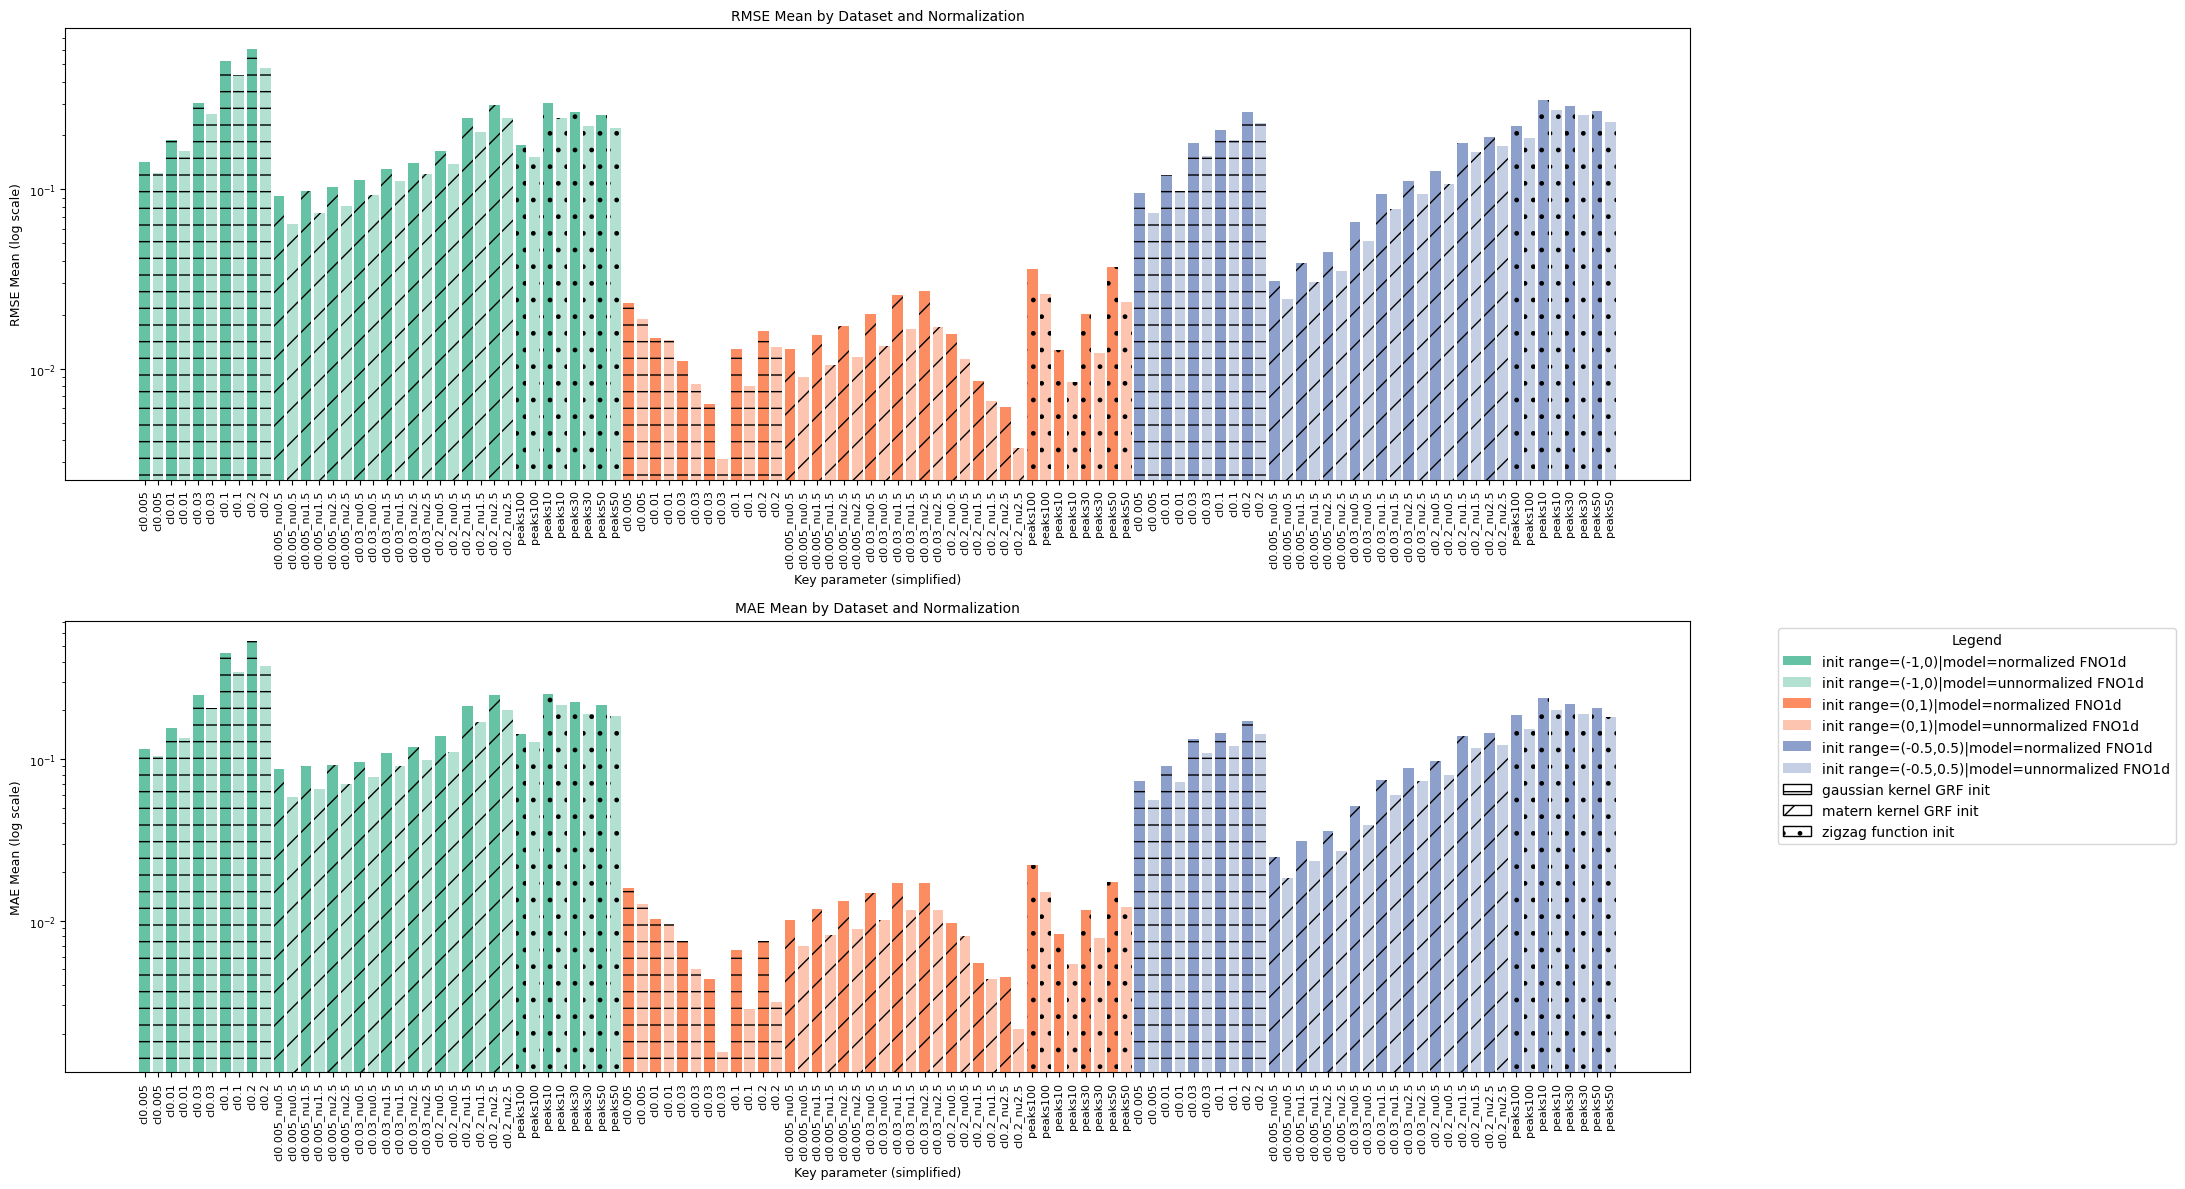

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import re

# 假设 summary_df 已经存在

# 你的颜色和 alpha 映射逻辑不变
dataset_types = summary_df['dataset_type'].unique()
base_colors = dict(zip(dataset_types, plt.cm.Set2.colors[:len(dataset_types)]))

def get_color(row):
    base = base_colors[row['dataset_type']]
    alpha = 1.0 if row['normalization'] == 'norm' else 0.5
    return (*base[:3], alpha)

colors = summary_df.apply(get_color, axis=1)

# 提取 pattern
def extract_pattern(name):
    name = name.lower()
    if 'matern' in name:
        return 'matern'
    elif 'gaussian' in name:
        return 'gaussian'
    elif 'zigzag' in name:
        return 'zigzag'
    else:
        return 'other'

summary_df['pattern'] = summary_df['dataset_name'].apply(extract_pattern)

hatch_map = {
    'matern': '/',
    'gaussian': '-',
    'zigzag': '.',
    'other': None
}
hatches = summary_df['pattern'].map(hatch_map)

# 这里是完整label，确保唯一定位（避免重合）
summary_df['label'] = (
    summary_df['dataset_type'] + "_" +
    summary_df['normalization'] + "_" +
    summary_df['dataset_name']
)

# 生成简短label_2，画图时显示用
def make_label_2(row):
    name = row['dataset_name'].lower()
    pattern = row['pattern']
    if pattern == 'matern':
        cl = re.search(r'cl([0-9\.]+)', name)
        nu = re.search(r'nu([0-9\.]+)', name)
        cl_str = cl.group(1) if cl else '?'
        nu_str = nu.group(1) if nu else '?'
        return f"cl{cl_str}_nu{nu_str}"
    elif pattern == 'gaussian':
        cl = re.search(r'cl([0-9\.]+)', name)
        cl_str = cl.group(1) if cl else '?'
        return f"cl{cl_str}"
    elif pattern == 'zigzag':
        peaks = re.search(r'peaks([0-9]+)', name)
        peaks_str = peaks.group(1) if peaks else '?'
        return f"peaks{peaks_str}"
    else:
        return 'other'

summary_df['label_2'] = summary_df.apply(make_label_2, axis=1)

# 画图
plt.figure(figsize=(22, 12))

# RMSE plot
plt.subplot(2, 1, 1)
bars = plt.bar(summary_df['label'], summary_df['rmse_mean'], color=colors)
for bar, hatch in zip(bars, hatches):
    if hatch:
        bar.set_hatch(hatch)

plt.yscale('log')
plt.xticks(ticks=range(len(summary_df['label'])), labels=summary_df['label_2'], rotation=90, fontsize=8)
plt.yticks(fontsize=8)
plt.title('RMSE Mean by Dataset and Normalization', fontsize=10)
plt.ylabel('RMSE Mean (log scale)', fontsize=9)
plt.xlabel('Key parameter (simplified)', fontsize=9)

# MAE plot
plt.subplot(2, 1, 2)
bars = plt.bar(summary_df['label'], summary_df['mae_mean'], color=colors)
for bar, hatch in zip(bars, hatches):
    if hatch:
        bar.set_hatch(hatch)

plt.yscale('log')
plt.xticks(ticks=range(len(summary_df['label'])), labels=summary_df['label_2'], rotation=90, fontsize=8)
plt.yticks(fontsize=8)
plt.title('MAE Mean by Dataset and Normalization', fontsize=10)
plt.ylabel('MAE Mean (log scale)', fontsize=9)
plt.xlabel('Key parameter (simplified)', fontsize=9)

# 映射字典：dataset_type -> 自定义显示文字
label_map = {
    'all_pos': 'range=(0,1)',
    'all_neg': 'range=(-1,0)',
    'pos_neg': 'range=(-0.5,0.5)',
}

legend_elements = []
for dtype in dataset_types:
    display_label = label_map.get(dtype, dtype)  # 如果没有定义，默认显示原字符串
    legend_elements.append(Patch(facecolor=base_colors[dtype], label=f'init {display_label}|model=normalized FNO1d', alpha=1.0))
    legend_elements.append(Patch(facecolor=base_colors[dtype], label=f'init {display_label}|model=unnormalized FNO1d', alpha=0.5))

pattern_hatches = {
    'gaussian': ('-', 'gaussian kernel GRF init'),
    'matern': ('/', 'matern kernel GRF init'),
    'zigzag': ('.', 'zigzag function init')
}
for hatch, label in pattern_hatches.values():
    legend_elements.append(Patch(facecolor='white', edgecolor='black', hatch=hatch, label=f'{label}'))

plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left', title='Legend')

plt.tight_layout()
plt.show()
